In [1]:
# 1.

import pandas as pd
from sklearn.feature_selection import f_classif

df = pd.read_csv('breast_cancer.csv')

X = df.drop(columns=['diagnosis'])          # 569*30 matrix for the features
y = df['diagnosis']                         # 569*1  vector for the diagnosis

F_statistics, p_values = f_classif(X, y)

# Print the F-Statistics and p-values, by feature, in a Data Frame
results = pd.DataFrame({                    
    'Feature': X.columns,
    'F_statistic': F_statistics,
    'p_value': p_values
})
print(' Table 1 - F-Statistics and p-values, by feature')
display(results)

# Rank features by discriminative power (highest F-statistic first)
ranked_results = results.sort_values(by='F_statistic', ascending=False).reset_index(drop=True)
print('\n Table 2 - Ranked features by discriminative power (highest F-statistic first)')
display(ranked_results)

# Remove features with p-value > 0.05
filtered_results = ranked_results[ranked_results['p_value'] <= 0.05].reset_index(drop=True)
print('\n Table 3 - Filtered features (only p-value <=0.05)')
display(filtered_results)

# Identify removed variables and store final dataset
removed_features = ranked_results[ranked_results['p_value'] > 0.05]['Feature'].tolist()
print(f"\n Removed features ({len(removed_features)}): {removed_features}")

# Updated matrix X for the filtered features
X= X[filtered_results['Feature']]

c:\Users\pmdin\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\pmdin\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


 Table 1 - F-Statistics and p-values, by feature


,Feature,F_statistic,p_value
0,radius_mean,646.981021,8.465941e-96
1,texture_mean,118.096059,4.058636e-25
2,perimeter_mean,697.235272,8.436251e-101
3,area_mean,573.060747,4.734564e-88
4,smoothness_mean,83.651123,1.051850e-18
5,compactness_mean,313.233079,3.938263e-56
6,concavity_mean,533.793126,9.966556e-84
7,concave points_mean,861.676020,7.101150e-116
8,symmetry_mean,69.527444,5.733384e-16
9,fractal_dimension_mean,0.093459,7.599368e-01



 Table 2 - Ranked features by discriminative power (highest F-statistic first)


,Feature,F_statistic,p_value
0,concave points_worst,964.385393,1.969100e-124
1,perimeter_worst,897.944219,5.771397e-119
2,concave points_mean,861.676020,7.101150e-116
3,radius_worst,860.781707,8.482292e-116
4,perimeter_mean,697.235272,8.436251e-101
5,area_worst,661.600206,2.828848e-97
6,radius_mean,646.981021,8.465941e-96
7,area_mean,573.060747,4.734564e-88
8,concavity_mean,533.793126,9.966556e-84
9,concavity_worst,436.691939,2.464664e-72



 Table 3 - Filtered features (only p-value <=0.05)


,Feature,F_statistic,p_value
0,concave points_worst,964.385393,1.969100e-124
1,perimeter_worst,897.944219,5.771397e-119
2,concave points_mean,861.676020,7.101150e-116
3,radius_worst,860.781707,8.482292e-116
4,perimeter_mean,697.235272,8.436251e-101
5,area_worst,661.600206,2.828848e-97
6,radius_mean,646.981021,8.465941e-96
7,area_mean,573.060747,4.734564e-88
8,concavity_mean,533.793126,9.966556e-84
9,concavity_worst,436.691939,2.464664e-72



 Removed features (5): ['fractal_dimension_se', 'smoothness_se', 'fractal_dimension_mean', 'texture_se', 'symmetry_se']


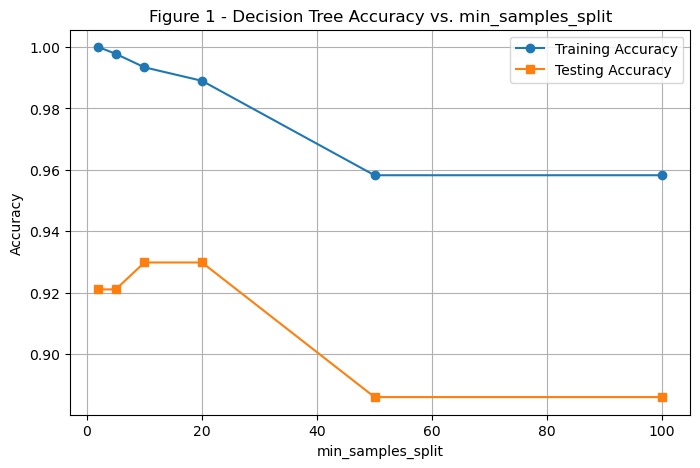

min_samples_split=  2 | Train Accuracy: 1.0000 | Test Accuracy: 0.9211
min_samples_split=  5 | Train Accuracy: 0.9978 | Test Accuracy: 0.9211
min_samples_split= 10 | Train Accuracy: 0.9934 | Test Accuracy: 0.9298
min_samples_split= 20 | Train Accuracy: 0.9890 | Test Accuracy: 0.9298
min_samples_split= 50 | Train Accuracy: 0.9582 | Test Accuracy: 0.8860
min_samples_split=100 | Train Accuracy: 0.9582 | Test Accuracy: 0.8860
Best Performing Decision Tree: min_samples_split=20 
(Test Accuracy: 0.9298)


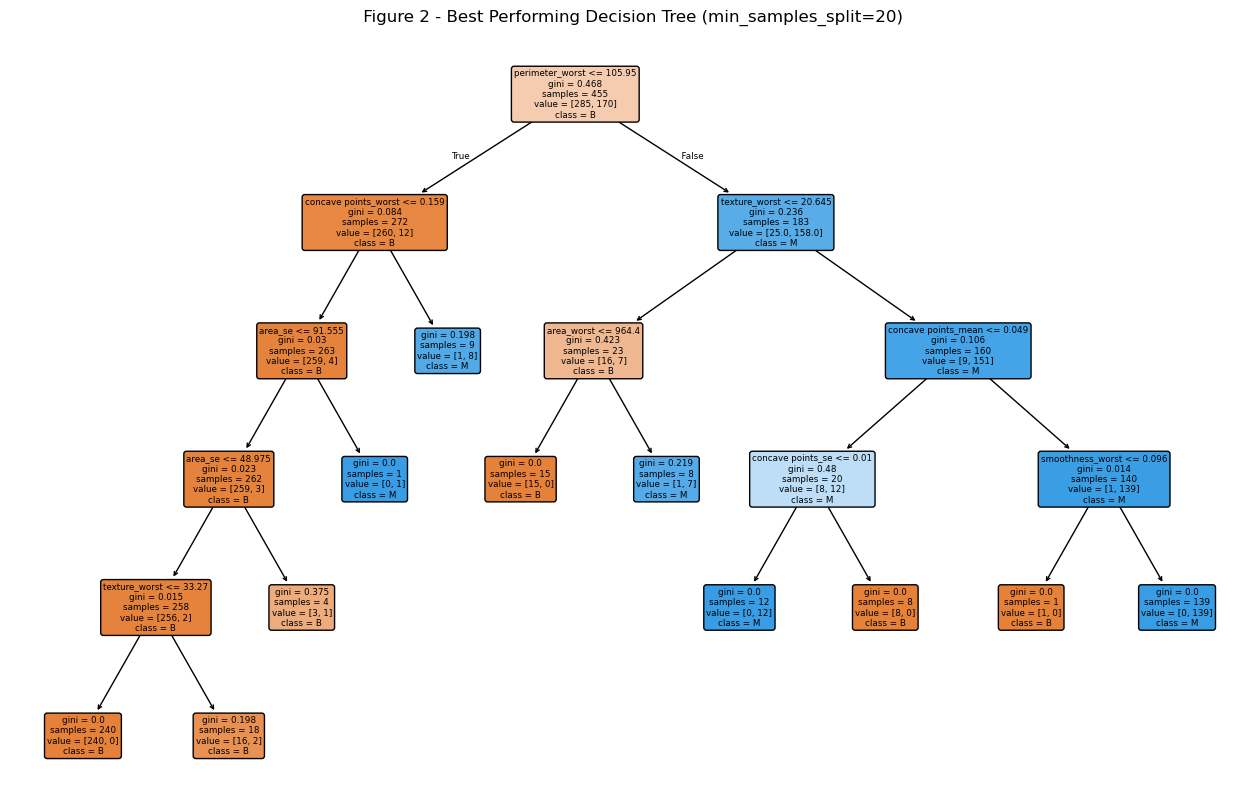

In [2]:
# 2. 

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Stratified 80-20 training-testing split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=1)

# Define candidate values for min_samples_split
min_samples_splits = [2, 5, 10, 20, 50, 100]
train_accuracies = []
test_accuracies = []
models = {}

# Train a decision tree for each hyperparameter value
for split in min_samples_splits:
    clf = DecisionTreeClassifier(min_samples_split=split, random_state=1)
    clf.fit(X_train, y_train)
    
    # Compute predictions
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    
    # Store accuracies
    train_accuracies.append(accuracy_score(y_train, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))
    models[split] = clf

# Plot 1: Assess training and testing accuracies of all trees
plt.figure(figsize=(8, 5))
plt.plot(min_samples_splits, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(min_samples_splits, test_accuracies, marker='s', label='Testing Accuracy')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.title('Figure 1 - Decision Tree Accuracy vs. min_samples_split')
plt.legend()
plt.grid(True)
plt.show()

# Print training and testing accuracies for all min_samples_split values (optional, for future memory to be able to give numerical values in the critical analysis)
for split, train_acc, test_acc in zip(min_samples_splits, train_accuracies, test_accuracies):
    print(f"min_samples_split={split:3d} | Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")


# Identify the best tree (highest test accuracy, breaking ties with larger min_samples_split)
max_test_acc = max(test_accuracies)
best_split = max([s for s, acc in zip(min_samples_splits, test_accuracies) if acc == max_test_acc])
best_model = models[best_split]
print(f"Best Performing Decision Tree: min_samples_split={best_split} \n(Test Accuracy: {max_test_acc:.4f})")

# Plot 2: Plot the best-performing decision tree structure
plt.figure(figsize=(16, 10))
plot_tree(
    best_model, 
    feature_names=X.columns, 
    class_names=best_model.classes_, 
    filled=True, 
    rounded=True
)
plt.title(f' Figure 2 - Best Performing Decision Tree (min_samples_split={best_split})')
plt.show()

In [8]:
# 3. Critical Analysis of Results and Model Generalization Capacity

''''
 The plot in Figure 1 shows how changing min_samples_split affects training 
 and testing accuracy across {2, 5, 10, 20, 50, 100}. The results reveal 
 three distinct regimes: overfitting, optimal generalization, and underfitting.

    Overfitting Regime (min_samples_split = 2, 5):
 At small values, the tree splits nodes almost without restriction. For 
 min_samples_split = 2, training accuracy reaches 1.0000, and for 5, it is 0.9978. 
 However, test accuracy stays at 0.9211 for both. This satisfies the definition 
 of overfitting: there exist alternative settings (like min_samples_split = 20) 
 with higher training error (lower training accuracy of 0.9890) but lower 
 testing error (higher test accuracy of 0.9298). The high training accuracy at 
 values 2 and 5 is deceptive because the tree memorizes noise and individual 
 training points rather than learning general patterns, reducing its 
 generalization capacity on new data.

    Optimal Generalization Window (min_samples_split = 10, 20):
 Increasing min_samples_split introduces early stopping, preventing the tree 
 from growing unnecessary branches. Training accuracy drops slightly to 0.9934 
 at min_samples_split = 10 and 0.9890 at 20. Crucially, test accuracy reaches 
 its peak value of 0.9298 in both settings. Comparing the two, setting 20 gives 
 a smaller gap between training and testing performance while maintaining equal 
 test accuracy. Following the tie-breaking rule, min_samples_split = 20 is 
 selected because a simpler, more regularized model offers better generalization 
 and lower variance when evaluating new patient samples.

    Underfitting Regime (min_samples_split = 50, 100):
 Setting min_samples_split to 50 or 100 stops tree growth prematurely, leaving 
 large leaf nodes with mixed classes. Training accuracy drops to 0.9583, and 
 test accuracy drops to 0.8860. The model becomes too simple, introducing high 
 bias that prevents it from capturing key decision boundaries, which degrades 
 both training and testing performance, reducing generalization capacity (lower
 testing accuracy and higher gap between training and testing performance).

    Impact of Feature Selection:
 The feature selection step in Exercise 1 directly helped this tuning process. 
 Filtering out features with p-values above 0.05 eliminated weak predictors, 
 keeping the distribution of biological signals with maximum variance based on 
 their F-statistic. Combining this F-statistic and p-value filtering with 
 hyperparameter tuning balanced bias and variance, maximizing test accuracy.''''

SyntaxError: unterminated string literal (detected at line 42) (3264817124.py, line 42)

In [9]:
# 4. Model Selection for clinical context

''' Model Recommendation:
Our group recommends Model B for initial breast cancer screening.

In an initial screening setting, false negatives (failing to identify a patient 
who actually has cancer) carry a severe, life-threatening cost, as delayed treatment 
can lead to disease progression. False positives (referring a healthy patient for 
further assessment) result in follow-up diagnostic testing and temporary anxiety, 
which is far more acceptable in early screening.

Recall measures the proportion of actual malignant cases correctly flagged by 
the model (True Positives / (True Positives + False Negatives)). Model B achieves 
a Recall of 98%, meaning it catches 98% of all cancer cases and misses only 2%. 
In contrast, Model A has a Recall of 88%, which misses 12% of malignant cases, which
must be avoided, since the cost of missing malignant cases is far bigger than
having false positives.

The trade-off in this case seems clear and easy to solve. Model A has higher
Precision (98% vs. 88%). Precision measures how many predicted positive cases are 
actually positive (True Positives / (True Positives + False Positives)), thus the
only advantage of Model A is if someone is diagnosed as positive, the degree of
certainty is much bigger, possibly avoiding further screening. 

Nonetheless, Model B Precision is still acceptable (88%), so Model B itself is
valuable for helping the diagnosis in its early phase. Since the question specifically
mentions there will be further clinical assessment, this should not pose a problem 
(further testing will reveal the False Positives).


For initial screening purposes, as asked, maximizing Recall to minimize false negatives
is the primary clinical priority, overriding extreme precision concerns, making Model B 
the preferred choice. '''

' Model Recommendation:\nOur group recommends Model B for initial breast cancer screening.\n\nIn an initial screening setting, false negatives (failing to identify a patient \nwho actually has cancer) carry a severe, life-threatening cost, as delayed treatment \ncan lead to disease progression. False positives (referring a healthy patient for \nfurther assessment) result in follow-up diagnostic testing and temporary anxiety, \nwhich is far more acceptable in early screening.\n\nRecall measures the proportion of actual malignant cases correctly flagged by \nthe model (True Positives / (True Positives + False Negatives)). Model B achieves \na Recall of 98%, meaning it catches 98% of all cancer cases and misses only 2%. \nIn contrast, Model A has a Recall of 88%, which misses 12% of malignant cases, which\nmust be avoided, since the cost of missing malignant cases is far bigger than\nhaving false positives.\n\nThe trade-off in this case seems clear and easy to solve. Model A has higher\nP

In [ ]:
%pip install "numpy<2.0" shap --no-deps --force-reinstall

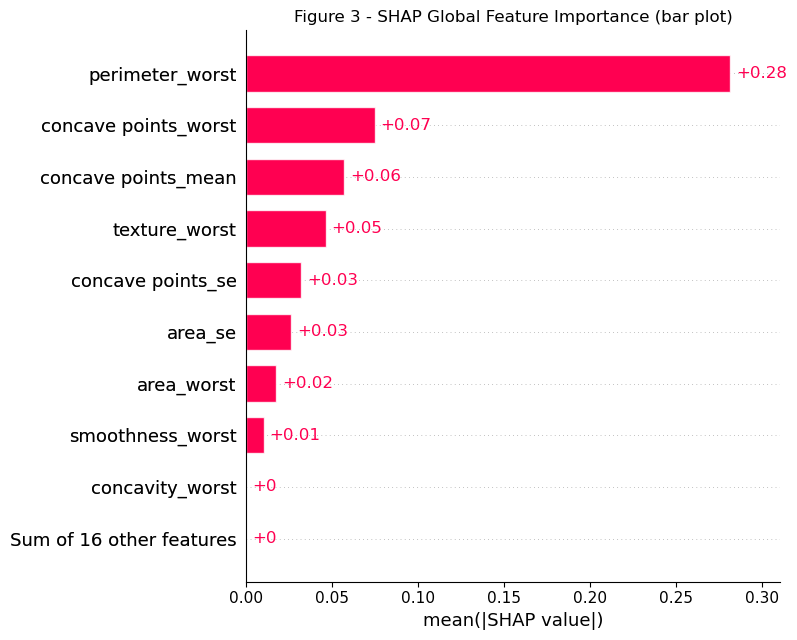

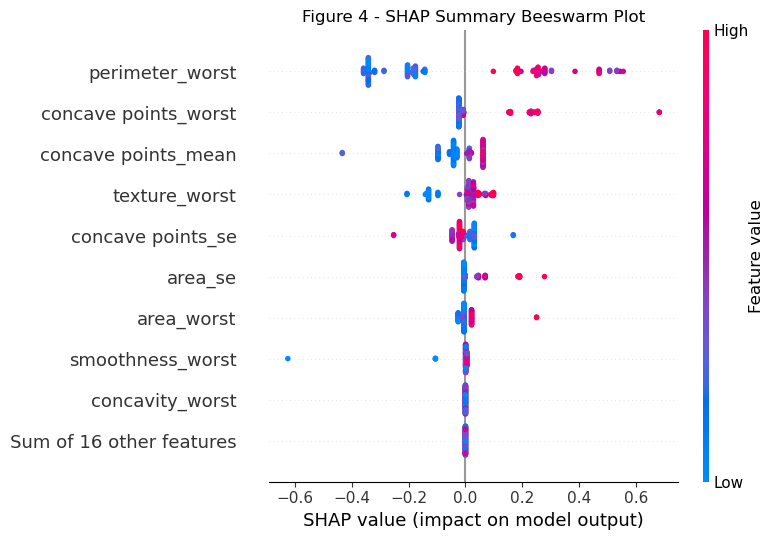

In [15]:
import matplotlib.pyplot as plt
import shap

# Initialize TreeExplainer using the best model
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values on the selected test set
shap_values = explainer(X_test)

# Handle output dimensions for scikit-learn binary classification, in order to isolate for the malignant case
if len(shap_values.shape) == 3:
    shap_values_target = shap_values[:, :, 1]
else:
    shap_values_target = shap_values

# 5a. Feature Importance Bar Plot
plt.figure()
shap.plots.bar(shap_values_target, show=False)
plt.title("Figure 3 - SHAP Global Feature Importance (bar plot)")
plt.tight_layout()
plt.show()

# 5b. Feature Impact Beeswarm Plot
plt.figure()
shap.plots.beeswarm(shap_values_target, show=False)
plt.title("Figure 4 - SHAP Summary Beeswarm Plot")
plt.tight_layout()
plt.show()

In [16]:
# 5. Answers

''' 
a.
Based on the mean absolute SHAP values displayed in the bar plot (shap.plots.bar), 
the two features with the greatest overall impact on predicting malignant breast 
cancer are "concave points_worst" and "perimeter_worst".

b.
For the "perimeter_worst" feature, high feature values (red points) lie on the right side of the baseline with
positive SHAP values (up to +0.55, most between +0.2 and +0.3), increasing the predicted probability of
malignancy. Low feature values (blue points) lie on the left side with negative SHAP values (down to -0.35, 
most between -0.35 and -0.2), decreasing the predicted probability of malignancy.

Under the specific clinical context, one might argue that enlarged nuclear perimeter directly reflects uncontrolled
cellular growth, serving as a primary morphological hallmark of malignant breast carcinoma.

For the "concave points_worst" feature, high feature values (red points) yield positive SHAP values (up to +0.68,
although that is an outlier - most between +0.15 and +0.3), increasing the predicted probability of malignancy.
Low feature values (blue points) cluster near or slightly below zero, exerting a neutral to negative
impact on malignancy probability.

Under the specific clinical context, one might argue that a higher count or severity of concave nuclear boundary
indentations indicates irregular nuclear membrane morphology and structural deformation, which strongly distinguishes
malignant tissue from uniform benign tissue. '''

' \na.\nBased on the mean absolute SHAP values displayed in the bar plot (shap.plots.bar), \nthe two features with the greatest overall impact on predicting malignant breast \ncancer are "concave points_worst" and "perimeter_worst".\n\nb.\nFor the "perimeter_worst" feature, high feature values (red points) lie on the right side of the baseline with\npositive SHAP values (up to +0.55, most between +0.2 and +0.3), increasing the predicted probability of\nmalignancy. Low feature values (blue points) lie on the left side with negative SHAP values (down to -0.35, \nmost between -0.35 and -0.2), decreasing the predicted probability of malignancy.\n\nUnder the specific clinical context, one might argue that enlarged nuclear perimeter directly reflects uncontrolled\ncellular growth, serving as a primary morphological hallmark of malignant breast carcinoma.\n\nFor the "concave points_worst" feature, high feature values (red points) yield positive SHAP values (up to +0.68,\nalthough that is an o